ld: warning: duplicate -rpath '/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib' ignored
ld: warning: duplicate -rpath '/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib' ignored
ld: warning: duplicate -rpath '/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib' ignored
ld: warning: duplicate -rpath '/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib' ignored
ld: warning: duplicate -rpath '/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib' ignored
ld: warning: duplicate -rpath '/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib' ignored
ld: warning: duplicate -rpath '/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib' ignored
ld: warning: duplicate -rpath '/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib' ignored
ld: warning: duplicate -rpath '/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib' ignored
ld: warning: duplicate -rpath '/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib' ignored


L2 error: 4.118e-04
Mean(uh) after normalization: -7.720e-17
KSP converged reason: 2


/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib/python3.11/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


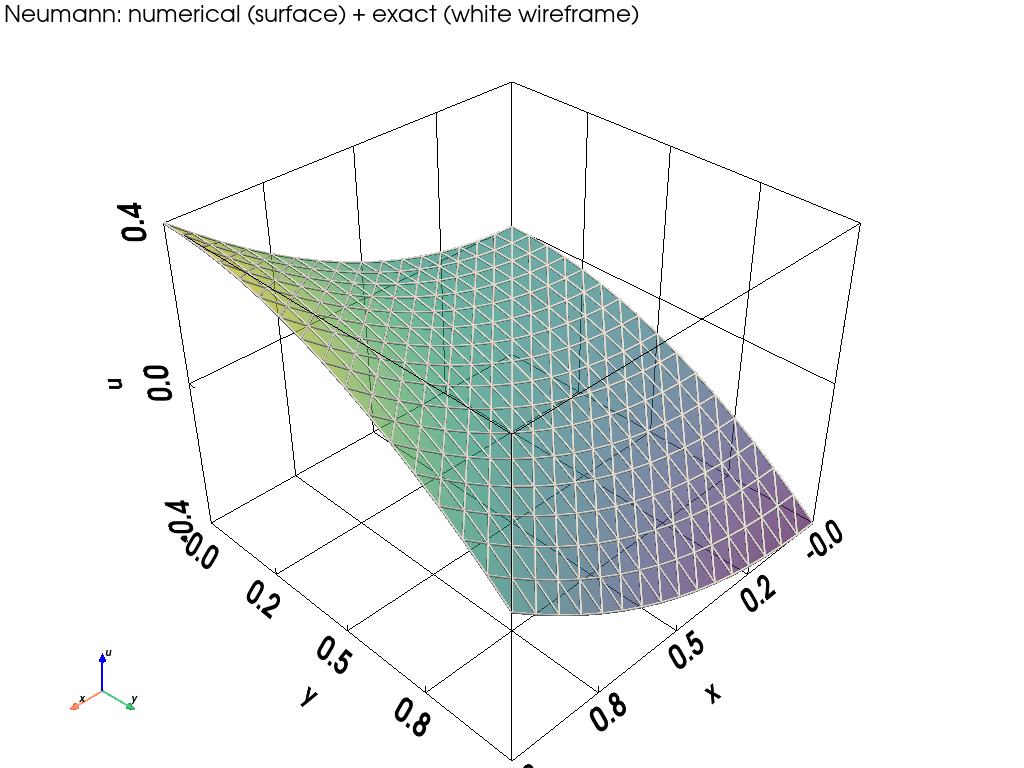

In [2]:
# Part II: Poisson with pure Neumann BC + zero-mean normalization

# Fix MPI/OFI finalization errors on macOS
import os

os.environ["FI_PROVIDER"] = "tcp"
os.environ["MPICH_OFI_STARTUP_CONNECT"] = "0"

from mpi4py import MPI
import numpy as np
from petsc4py import PETSc
from dolfinx import mesh, fem, plot, io
import ufl
import pyvista

# Mesh
msh = mesh.create_rectangle(
    comm=MPI.COMM_WORLD,
    points=((0.0, 0.0), (1.0, 1.0)),
    n=(16, 16),
    cell_type=mesh.CellType.triangle,
)

# Function space
V = fem.functionspace(msh, ("CG", 1))
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

# Exact solution with non-trivial Neumann flux
X = ufl.SpatialCoordinate(msh)
u_exact = X[0]**2 - X[1]**2
f = -ufl.div(ufl.grad(u_exact))  # here f = 0
n = ufl.FacetNormal(msh)
g = ufl.dot(ufl.grad(u_exact), n)  # Neumann data du/dn

# Weak form for pure Neumann problem
a = ufl.inner(ufl.grad(u), ufl.grad(v)) * ufl.dx
L = f * v * ufl.dx + g * v * ufl.ds

a_form = fem.form(a)
L_form = fem.form(L)

# Assemble singular system
A = fem.petsc.assemble_matrix(a_form, bcs=[])
A.assemble()
b = fem.petsc.assemble_vector(L_form)

# Handle nullspace (constants) for pure Neumann
nullspace = PETSc.NullSpace().create(constant=True, comm=msh.comm)
A.setNullSpace(nullspace)
nullspace.remove(b)

ksp = PETSc.KSP().create(msh.comm)
ksp.setOperators(A)
ksp.setType("cg")
ksp.getPC().setType("hypre")
ksp.setTolerances(rtol=1e-12)
ksp.setFromOptions()

uh = fem.Function(V)
ksp.solve(b, uh.x.petsc_vec)
uh.x.scatter_forward()

# Enforce zero-mean representative
vol = fem.assemble_scalar(fem.form(1.0 * ufl.dx(domain=msh)))
mean_uh = fem.assemble_scalar(fem.form(uh * ufl.dx)) / vol
uh.x.array[:] -= mean_uh
uh.x.scatter_forward()

# Shift exact solution to same zero-mean representative
mean_ue = fem.assemble_scalar(fem.form(u_exact * ufl.dx)) / vol
u_exact_zero = u_exact - mean_ue

l2_error = np.sqrt(
    fem.assemble_scalar(fem.form(ufl.inner(uh - u_exact_zero, uh - u_exact_zero) * ufl.dx))
)
mean_after = fem.assemble_scalar(fem.form(uh * ufl.dx)) / vol

print(f"L2 error: {l2_error:.3e}")
print(f"Mean(uh) after normalization: {mean_after:.3e}")
print(f"KSP converged reason: {ksp.getConvergedReason()}")

###############################
# Plotting with pyvista (3D)
# Numerical (surface) + exact (white wireframe)
###############################
cells, types, points = plot.vtk_mesh(V)
grid_num = pyvista.UnstructuredGrid(cells, types, points)
grid_num.point_data["u"] = uh.x.array.real
grid_num.set_active_scalars("u")

u_exact_fun = fem.Function(V)
u_exact_fun.interpolate(lambda xx: xx[0]**2 - xx[1]**2)
mean_u_exact_fun = fem.assemble_scalar(fem.form(u_exact_fun * ufl.dx)) / vol
u_exact_fun.x.array[:] -= mean_u_exact_fun
u_exact_fun.x.scatter_forward()

grid_exact = pyvista.UnstructuredGrid(cells, types, points)
grid_exact.point_data["u_exact"] = u_exact_fun.x.array.real
grid_exact.set_active_scalars("u_exact")

warp_factor = 0.4
warped_num = grid_num.warp_by_scalar("u", factor=warp_factor)
warped_exact = grid_exact.warp_by_scalar("u_exact", factor=warp_factor)

plotter = pyvista.Plotter()
plotter.add_mesh(
    warped_num,
    scalars="u",
    cmap="viridis",
    show_scalar_bar=False,
    show_edges=True,
    edge_color="black",
    line_width=0.6,
    opacity=0.65,
    smooth_shading=True,
    lighting=True,
)
plotter.add_mesh(
    warped_exact,
    style="wireframe",
    color="white",
    line_width=2.4,
    render_lines_as_tubes=True,
    opacity=1.0,
)
plotter.add_text("Neumann: numerical (surface) + exact (white wireframe)", font_size=14)
plotter.show_bounds(
    grid="back",
    location="outer",
    all_edges=True,
    xtitle="x",
    ytitle="y",
    ztitle="u",
    font_size=25,
    n_zlabels=3,
)
plotter.add_axes(xlabel="x", ylabel="y", zlabel="u")
plotter.view_isometric()
plotter.show()

with io.XDMFFile(msh.comm, "output/poisson_neumann.xdmf", "w") as file:
    file.write_mesh(msh)
    file.write_function(uh)

In [3]:
# Convergence study for pure Neumann problem (run after cell 1)
mesh_sizes = [8, 16, 32, 64]
hs = []
errors = []

for n_cells in mesh_sizes:
    msh_i = mesh.create_rectangle(
        comm=MPI.COMM_WORLD,
        points=((0.0, 0.0), (1.0, 1.0)),
        n=(n_cells, n_cells),
        cell_type=mesh.CellType.triangle,
    )

    V_i = fem.functionspace(msh_i, ("CG", 1))
    u_i = ufl.TrialFunction(V_i)
    v_i = ufl.TestFunction(V_i)

    Xi = ufl.SpatialCoordinate(msh_i)
    u_exact_i = Xi[0]**2 - Xi[1]**2
    f_i = -ufl.div(ufl.grad(u_exact_i))
    n_i = ufl.FacetNormal(msh_i)
    g_i = ufl.dot(ufl.grad(u_exact_i), n_i)

    a_i = ufl.inner(ufl.grad(u_i), ufl.grad(v_i)) * ufl.dx
    L_i = f_i * v_i * ufl.dx + g_i * v_i * ufl.ds

    A_i = fem.petsc.assemble_matrix(fem.form(a_i), bcs=[])
    A_i.assemble()
    b_i = fem.petsc.assemble_vector(fem.form(L_i))

    nullspace_i = PETSc.NullSpace().create(constant=True, comm=msh_i.comm)
    A_i.setNullSpace(nullspace_i)
    nullspace_i.remove(b_i)

    ksp_i = PETSc.KSP().create(msh_i.comm)
    ksp_i.setOperators(A_i)
    ksp_i.setType("cg")
    ksp_i.getPC().setType("hypre")
    ksp_i.setTolerances(rtol=1e-12)
    ksp_i.setFromOptions()

    uh_i = fem.Function(V_i)
    ksp_i.solve(b_i, uh_i.x.petsc_vec)
    uh_i.x.scatter_forward()

    vol_i = fem.assemble_scalar(fem.form(1.0 * ufl.dx(domain=msh_i)))
    mean_uh_i = fem.assemble_scalar(fem.form(uh_i * ufl.dx)) / vol_i
    uh_i.x.array[:] -= mean_uh_i
    uh_i.x.scatter_forward()

    mean_ue_i = fem.assemble_scalar(fem.form(u_exact_i * ufl.dx)) / vol_i
    u_exact_zero_i = u_exact_i - mean_ue_i

    l2_i = np.sqrt(
        fem.assemble_scalar(fem.form(ufl.inner(uh_i - u_exact_zero_i, uh_i - u_exact_zero_i) * ufl.dx))
    )

    hs.append(1.0 / n_cells)
    errors.append(l2_i)

if msh.comm.rank == 0:
    print("n      h          L2-error      rate")
    for i, (n_cells, h_i, e_i) in enumerate(zip(mesh_sizes, hs, errors)):
        if i == 0:
            print(f"{n_cells:<6d} {h_i:>8.4f}   {e_i:>10.4e}   {'-':>5}")
        else:
            rate_i = np.log(errors[i - 1] / e_i) / np.log(hs[i - 1] / h_i)
            print(f"{n_cells:<6d} {h_i:>8.4f}   {e_i:>10.4e}   {rate_i:>5.2f}")

ld: warning: duplicate -rpath '/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib' ignored
ld: warning: duplicate -rpath '/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib' ignored
ld: warning: duplicate -rpath '/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib' ignored
ld: warning: duplicate -rpath '/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib' ignored
ld: warning: duplicate -rpath '/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib' ignored
ld: warning: duplicate -rpath '/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib' ignored


n      h          L2-error      rate
8        0.1250   1.6470e-03       -
16       0.0625   4.1175e-04    2.00
32       0.0312   1.0294e-04    2.00
64       0.0156   2.5735e-05    2.00


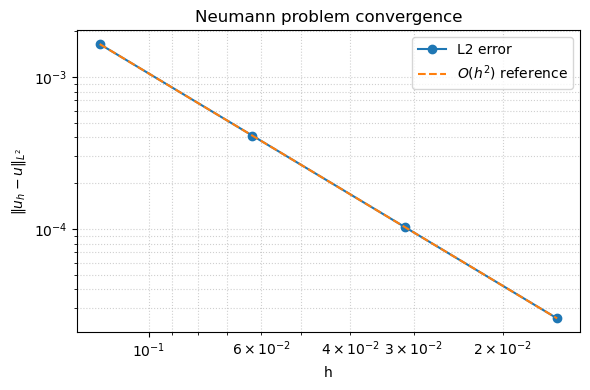

In [4]:
# Log-log convergence plot (run after cell 2)
import matplotlib.pyplot as plt

hs_arr = np.array(hs)
errors_arr = np.array(errors)

# Reference O(h^2) line anchored at first data point
ref = errors_arr[0] * (hs_arr / hs_arr[0])**2

plt.figure(figsize=(6, 4))
plt.loglog(hs_arr, errors_arr, "o-", label="L2 error")
plt.loglog(hs_arr, ref, "--", label=r"$O(h^2)$ reference")
plt.gca().invert_xaxis()
plt.xlabel("h")
plt.ylabel(r"$\|u_h - u\|_{L^2}$")
plt.title("Neumann problem convergence")
plt.grid(True, which="both", ls=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()